<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №3

In [1]:
import os
import re
import string
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


##Зберіть код та навчіть модель Skip-Gram на заданому датасеті.

Кількість речень: 179063
Приклад: ['1 1/4 cups cooked and pureed fresh butternut squash, or 1 10-ounce package frozen squash, defrosted', '1 cup peeled and cooked fresh chestnuts (about 20), or 1 cup canned, unsweetened chestnuts', '1 medium-size onion, peeled and chopped']
Train: 125344
Val: 53719
Розмір словника: 6033
Максимальний індекс: 6032
Розмір word_freq: (6033,)
Сума частот: 772849
Epoch 1: Train Loss = 23.9900, Val Loss = 23.9396
Epoch 2: Train Loss = 23.9202, Val Loss = 23.9129
Epoch 3: Train Loss = 23.9015, Val Loss = 23.9066
Epoch 4: Train Loss = 23.8921, Val Loss = 23.9051
Epoch 5: Train Loss = 23.8867, Val Loss = 23.9033
Epoch 6: Train Loss = 23.8847, Val Loss = 23.9034
Epoch 7: Train Loss = 23.8820, Val Loss = 23.9061
Epoch 8: Train Loss = 23.8819, Val Loss = 23.9080
Epoch 9: Train Loss = 23.8808, Val Loss = 23.9110
Epoch 10: Train Loss = 23.8816, Val Loss = 23.9121


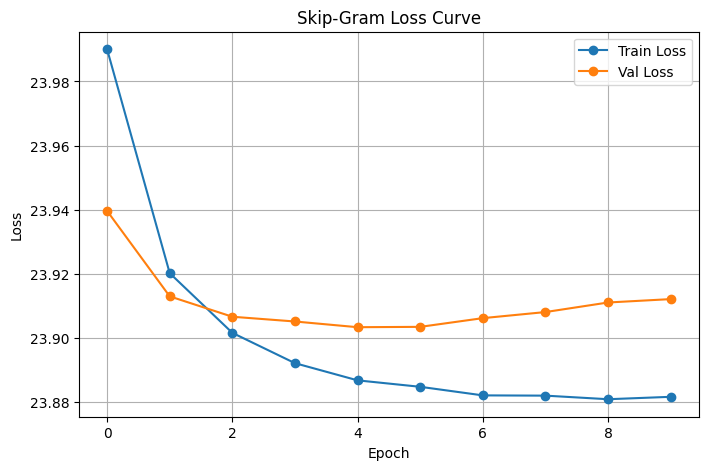

In [3]:
url = "https://raw.githubusercontent.com/nytimes/ingredient-phrase-tagger/master/nyt-ingredients-snapshot-2015.csv"
file_path = "nyt-ingredients-snapshot-2015.csv"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

df = pd.read_csv(file_path, encoding="utf-8")
sentences = df["input"].dropna().astype(str).tolist()

print("Кількість речень:", len(sentences))
print("Приклад:", sentences[:3])

def tokenize(sentence):
    return re.findall(r'\b\w+\b', sentence.lower())

tokenized_sentences = [tokenize(s) for s in sentences]

np.random.seed(42)
np.random.shuffle(tokenized_sentences)

split_idx = int(0.7 * len(tokenized_sentences))
train_sentences = tokenized_sentences[:split_idx]
val_sentences = tokenized_sentences[split_idx:]

print("Train:", len(train_sentences))
print("Val:", len(val_sentences))

stop_words = {
    "a","an","the","and","or","but","if","then","else","for","on","in","at","by",
    "with","from","to","of","this","that","these","those","is","are","was","were",
    "be","been","being","have","has","had","do","does","did","not","no","yes",
    "it","its","as","can","will","just","so","such","up","down","out","over","under"
}

def is_valid_token(word):
    return (
        word not in stop_words and
        word not in string.punctuation and
        not word.isdigit() and
        len(word) > 1
    )

word_counts = {}
for sentence in train_sentences:
    for word in sentence:
        if is_valid_token(word):
            word_counts[word] = word_counts.get(word, 0) + 1

min_freq = 1
max_freq = int(0.1 * len(train_sentences))

filtered_words = [
    word for word, count in word_counts.items()
    if min_freq <= count <= max_freq
]

vocab = {"<PAD>": 0}
for i, word in enumerate(filtered_words, start=1):
    vocab[word] = i

id_to_word = {idx: word for word, idx in vocab.items()}

print("Розмір словника:", len(vocab))
print("Максимальний індекс:", max(vocab.values()))

word_freq = np.zeros(len(vocab), dtype=np.int64)

for sentence in train_sentences:
    for word in sentence:
        idx = vocab.get(word, 0)
        word_freq[idx] += 1

word_freq[0] = max(word_freq[0], 1)

print("Розмір word_freq:", word_freq.shape)
print("Сума частот:", word_freq.sum())

class PaddedSequenceDataset(Dataset):
    def __init__(self, sentences, vocab, max_len=20):
        self.sentences = sentences
        self.vocab = vocab
        self.max_len = max_len
        self.vocab_size = len(vocab)

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]

        encoded = []
        for word in sentence:
            token_id = self.vocab.get(word, 0)
            if token_id < 0 or token_id >= self.vocab_size:
                token_id = 0
            encoded.append(token_id)

        if len(encoded) < self.max_len:
            encoded += [0] * (self.max_len - len(encoded))

        encoded = encoded[:self.max_len]
        return torch.tensor(encoded, dtype=torch.long)

max_len = 20
train_dataset = PaddedSequenceDataset(train_sentences, vocab, max_len=max_len)
val_dataset = PaddedSequenceDataset(val_sentences, vocab, max_len=max_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, pad_idx=0):
        super().__init__()
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.init_weights(self.center_embeddings)
        self.init_weights(self.context_embeddings)

    def init_weights(self, emb):
        bound = 1.0 / (emb.embedding_dim ** 0.5)
        nn.init.uniform_(emb.weight, -bound, bound)
        emb.weight.data = F.normalize(emb.weight.data, dim=1)

    def forward(self, center_words, context_words):
        center_vec = self.center_embeddings(center_words)
        context_vec = self.context_embeddings(context_words)
        return torch.sum(center_vec * context_vec, dim=1)

def create_context_mask(sentence_length, window_size):
    mask = torch.zeros((sentence_length, sentence_length), dtype=torch.float32)
    half = window_size // 2
    for i in range(sentence_length):
        start = max(0, i - half)
        end = min(sentence_length, i + half + 1)
        mask[i, start:end] = 1.0
    return mask

def sample_negative_words(vocab_size, batch_size, num_negatives, word_freq):
    probs = word_freq.astype(np.float64)
    probs = probs / probs.sum()

    negatives = np.random.choice(
        np.arange(vocab_size),
        size=(batch_size, num_negatives),
        p=probs
    )

    negatives = np.clip(negatives, 0, vocab_size - 1)
    return torch.tensor(negatives, dtype=torch.long)

class SkipGramTrainer:
    def __init__(self, vocab_size, embedding_dim, pad_idx=0, window_size=10, num_negatives=5, word_freq=None):
        self.model = SkipGramModel(vocab_size, embedding_dim, pad_idx).to(device)
        self.window_size = window_size
        self.num_negatives = num_negatives
        self.vocab_size = vocab_size
        self.word_freq = word_freq

    def forward(self, batch):
        B, L = batch.shape

        batch = torch.clamp(batch, 0, self.vocab_size - 1)

        center = self.model.center_embeddings(batch)
        context = self.model.context_embeddings(batch).transpose(1, 2)

        scores = torch.bmm(center, context)

        mask = create_context_mask(L, self.window_size).to(batch.device)
        positive_probs = torch.sigmoid(scores) * mask
        pos_loss = -torch.log(positive_probs + 1e-9).sum() / (mask.sum() * B + 1e-9)

        neg_samples = sample_negative_words(
            vocab_size=self.vocab_size,
            batch_size=B,
            num_negatives=self.num_negatives,
            word_freq=self.word_freq
        ).to(batch.device)

        neg_samples = torch.clamp(neg_samples, 0, self.vocab_size - 1)

        center_mean = center.mean(dim=1)
        neg_emb = self.model.context_embeddings(neg_samples)

        neg_scores = torch.sum(center_mean.unsqueeze(1) * neg_emb, dim=2)
        neg_loss = -torch.log(1 - torch.sigmoid(neg_scores) + 1e-9).mean()

        return pos_loss + neg_loss

def train_eval_loop(trainer, train_loader, val_loader, epochs=10, lr=0.01):
    optimizer = optim.Adam(trainer.model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        trainer.model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()
            loss = trainer.forward(batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_losses.append(train_loss)

        trainer.model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                loss = trainer.forward(batch)
                total_val_loss += loss.item()

        val_loss = total_val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    return train_losses, val_losses

trainer = SkipGramTrainer(
    vocab_size=len(vocab),
    embedding_dim=100,
    pad_idx=0,
    window_size=10,
    num_negatives=5,
    word_freq=word_freq
)

train_losses, val_losses = train_eval_loop(
    trainer,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.01
)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Skip-Gram Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

### Проаналізуйте які значення втрат на тренувальній та валідаційній вибірках ви отримали? Як змінюються криві втрат із кожною епохою?

Було навчено модель Skip-Gram на заданому датасеті. У процесі навчання значення втрат на тренувальній вибірці поступово зменшувалися з 23.9900 до 23.8816, а на валідаційній - з 23.9396 до 23.9121. Криві втрат на перших епохах знижуються, що свідчить про навчання моделі, а далі виходять майже на плато. При цьому після 5-6 епох валідаційна втрата майже не покращується і починає
трохи зростати, що може вказувати на початок перенавчання.

##Порівняння різних параметрів навчання.

In [4]:
def run_experiment(window_size=10, num_negatives=5, embedding_dim=100):
    print(f"\n=== window={window_size}, neg={num_negatives}, emb={embedding_dim} ===")

    trainer = SkipGramTrainer(
        vocab_size=len(vocab),
        embedding_dim=embedding_dim,
        pad_idx=0,
        window_size=window_size,
        num_negatives=num_negatives,
        word_freq=word_freq
    )

    train_losses, val_losses = train_eval_loop(
        trainer,
        train_loader,
        val_loader,
        epochs=5,
        lr=0.01
    )

    return train_losses[-1], val_losses[-1]

###Розмір контекстного вікна

In [5]:
w1 = run_experiment(window_size=4)
w2 = run_experiment(window_size=10)
w3 = run_experiment(window_size=20)


=== window=4, neg=5, emb=100 ===
Epoch 1: Train Loss = 68.5031, Val Loss = 68.4560
Epoch 2: Train Loss = 68.4355, Val Loss = 68.4329
Epoch 3: Train Loss = 68.4149, Val Loss = 68.4260
Epoch 4: Train Loss = 68.4043, Val Loss = 68.4242
Epoch 5: Train Loss = 68.3995, Val Loss = 68.4268

=== window=10, neg=5, emb=100 ===
Epoch 1: Train Loss = 24.0141, Val Loss = 23.9627
Epoch 2: Train Loss = 23.9455, Val Loss = 23.9393
Epoch 3: Train Loss = 23.9266, Val Loss = 23.9312
Epoch 4: Train Loss = 23.9170, Val Loss = 23.9297
Epoch 5: Train Loss = 23.9111, Val Loss = 23.9277

=== window=20, neg=5, emb=100 ===
Epoch 1: Train Loss = 7.1537, Val Loss = 7.0930
Epoch 2: Train Loss = 7.0744, Val Loss = 7.0668
Epoch 3: Train Loss = 7.0532, Val Loss = 7.0579
Epoch 4: Train Loss = 7.0464, Val Loss = 7.0521
Epoch 5: Train Loss = 7.0408, Val Loss = 7.0532


###Кількість негативних прикладів

In [6]:
n1 = run_experiment(num_negatives=2)
n2 = run_experiment(num_negatives=5)
n3 = run_experiment(num_negatives=10)


=== window=10, neg=2, emb=100 ===
Epoch 1: Train Loss = 24.0578, Val Loss = 24.0013
Epoch 2: Train Loss = 23.9825, Val Loss = 23.9710
Epoch 3: Train Loss = 23.9593, Val Loss = 23.9611
Epoch 4: Train Loss = 23.9495, Val Loss = 23.9599
Epoch 5: Train Loss = 23.9463, Val Loss = 23.9595

=== window=10, neg=5, emb=100 ===
Epoch 1: Train Loss = 24.0158, Val Loss = 23.9642
Epoch 2: Train Loss = 23.9457, Val Loss = 23.9396
Epoch 3: Train Loss = 23.9273, Val Loss = 23.9322
Epoch 4: Train Loss = 23.9184, Val Loss = 23.9279
Epoch 5: Train Loss = 23.9116, Val Loss = 23.9300

=== window=10, neg=10, emb=100 ===
Epoch 1: Train Loss = 24.0064, Val Loss = 23.9556
Epoch 2: Train Loss = 23.9381, Val Loss = 23.9350
Epoch 3: Train Loss = 23.9211, Val Loss = 23.9266
Epoch 4: Train Loss = 23.9117, Val Loss = 23.9260
Epoch 5: Train Loss = 23.9061, Val Loss = 23.9247


###Розмір ембеддінгів

In [7]:
e1 = run_experiment(embedding_dim=50)
e2 = run_experiment(embedding_dim=100)
e3 = run_experiment(embedding_dim=200)


=== window=10, neg=5, emb=50 ===
Epoch 1: Train Loss = 24.0739, Val Loss = 24.0215
Epoch 2: Train Loss = 24.0009, Val Loss = 23.9907
Epoch 3: Train Loss = 23.9775, Val Loss = 23.9790
Epoch 4: Train Loss = 23.9667, Val Loss = 23.9740
Epoch 5: Train Loss = 23.9593, Val Loss = 23.9702

=== window=10, neg=5, emb=100 ===
Epoch 1: Train Loss = 24.0616, Val Loss = 24.0096
Epoch 2: Train Loss = 23.9930, Val Loss = 23.9862
Epoch 3: Train Loss = 23.9729, Val Loss = 23.9778
Epoch 4: Train Loss = 23.9638, Val Loss = 23.9757
Epoch 5: Train Loss = 23.9582, Val Loss = 23.9759

=== window=10, neg=5, emb=200 ===
Epoch 1: Train Loss = 24.0160, Val Loss = 23.9697
Epoch 2: Train Loss = 23.9538, Val Loss = 23.9523
Epoch 3: Train Loss = 23.9385, Val Loss = 23.9508
Epoch 4: Train Loss = 23.9374, Val Loss = 23.9560
Epoch 5: Train Loss = 23.9389, Val Loss = 23.9622


Збільшення розміру контекстного вікна призводить до значного зменшення значення функції втрат (з 68.42 при window=4 до 7.05 при window=20), що пояснюється врахуванням ширшого контексту. Збільшення кількості негативних прикладів покращує якість навчання (найкращий результат при num_negatives=10 = 23.9247), оскільки модель краще розрізняє правильні та випадкові зв’язки. Збільшення розміру ембеддінгів також позитивно впливає на якість (найкраще при embedding_dim=200 = 23.9508), оскільки дозволяє точніше відобразити семантичні зв’язки між словами.

##Пошук найбільш схожих слів. Використовуйте функцію most_similar для пошуку найближчих слів до заданого.

In [8]:
embeddings = trainer.model.center_embeddings.weight.data

def most_similar(word, vocab, embeddings, top_k=5):
    if word not in vocab:
        return f"Слова '{word}' немає у словнику."

    word_idx = vocab[word]
    word_vector = embeddings[word_idx].unsqueeze(0)

    similarities = F.cosine_similarity(word_vector, embeddings)
    similarities[word_idx] = -1  # щоб саме слово не поверталось
    similarities[vocab["<PAD>"]] = -1

    top_indices = torch.topk(similarities, top_k).indices.tolist()

    idx_to_word = {idx: w for w, idx in vocab.items()}
    result = [(idx_to_word[idx], float(similarities[idx])) for idx in top_indices]

    return result

In [9]:
words_to_check = ["cheese", "cake", "coffee"]

for word in words_to_check:
    print(f"\nНайбільш схожі слова до '{word}':")
    result = most_similar(word, vocab, embeddings, top_k=5)
    print(result)


Найбільш схожі слова до 'cheese':
[('mozzarella', 0.7523003816604614), ('ricotta', 0.6581581234931946), ('reggiano', 0.6491502523422241), ('pecorino', 0.6222588419914246), ('parmigiano', 0.6221634149551392)]

Найбільш схожі слова до 'cake':
[('curd', 0.41966086626052856), ('christophine', 0.41086748242378235), ('okra', 0.4042874574661255), ('purpose', 0.3988643288612366), ('yeast', 0.39789873361587524)]

Найбільш схожі слова до 'coffee':
[('espresso', 0.5480881929397583), ('praline', 0.5326241850852966), ('ldcarlson', 0.4670897424221039), ('tisane', 0.46494030952453613), ('mincemeat', 0.46166908740997314)]


###Які слова були знайдені? Чи відповідають вони вашим очікуванням?

За допомогою функції most_similar було знайдено найближчі слова для заданих прикладів. Для слова “cheese” модель коректно визначила схожі слова, такі як mozzarella, ricotta, parmigiano, що повністю відповідає очікуванням. Для слова “coffee” також отримано релевантні результати (espresso), хоча присутні і менш пов’язані слова. У випадку слова “cake” результати є менш точними, оскільки модель повертає слова, які не завжди семантично близькі. Це свідчить про те, що якість ембеддінгів залежить від контексту в датасеті та частоти слів.


In [12]:
embeddings = trainer.model.center_embeddings.weight.data
idx_to_word = {idx: word for word, idx in vocab.items()}

def analogy(word_a, word_b, word_c, vocab, embeddings, top_k=5):
    for word in [word_a, word_b, word_c]:
        if word not in vocab:
            return f"Слова '{word}' немає у словнику."

    a_idx = vocab[word_a]
    b_idx = vocab[word_b]
    c_idx = vocab[word_c]

    target_vector = embeddings[b_idx] - embeddings[a_idx] + embeddings[c_idx]

    similarities = F.cosine_similarity(target_vector.unsqueeze(0), embeddings)

    similarities[a_idx] = -1
    similarities[b_idx] = -1
    similarities[c_idx] = -1
    similarities[vocab["<PAD>"]] = -1

    top_indices = torch.topk(similarities, top_k).indices.tolist()
    result = [(idx_to_word[idx], float(similarities[idx])) for idx in top_indices]

    return result

In [13]:
print("king : man :: queen : ?")
print(analogy("king", "man", "queen", vocab, embeddings, top_k=5))

print("\ncake : cacao :: cheese : ?")
print(analogy("cake", "cacao", "cheese", vocab, embeddings, top_k=5))

king : man :: queen : ?
Слова 'man' немає у словнику.

cake : cacao :: cheese : ?
[('mozzarella', 0.5181871652603149), ('germain', 0.5154837369918823), ('taleggio', 0.5042291879653931), ('limoncello', 0.5035015344619751), ('solution', 0.4992687404155731)]


###Чи коректно модель розв'язує ці задачі? Чому?

Під час перевірки аналогій модель не змогла коректно розв’язати приклад king : man :: queen : ?, оскільки слово man відсутнє у словнику. Це пояснюється тим, що модель навчалась на датасеті рецептів, а не на загальномовному корпусі. Для аналогії cake : cacao :: cheese : ? модель повернула слова, пов’язані з сиром, зокрема mozzarella і taleggio, тобто частково результат є логічним. Отже, модель краще працює з аналогіями в межах тематики датасету

##Задайте власні слова для функції аналогії та аналізу схожості.

In [14]:
print("butter:", most_similar("butter", vocab, embeddings))
print("milk:", most_similar("milk", vocab, embeddings))
print("sugar:", most_similar("sugar", vocab, embeddings))

butter: [('margarine', 0.7226444482803345), ('lard', 0.6934437155723572), ('dukkah', 0.6556670069694519), ('shortening', 0.6417571902275085), ('colatura', 0.6354135274887085)]
milk: [('buttermilk', 0.7547224760055542), ('kefir', 0.743502676486969), ('leche', 0.7105305194854736), ('cream', 0.7015283107757568), ('yogurt', 0.6897088885307312)]
sugar: [('honey', 0.6943435668945312), ('molasses', 0.6857752799987793), ('gooseberry', 0.6812253594398499), ('colatura', 0.6799317598342896), ('vouvray', 0.6773641705513)]


In [15]:
print("milk : cow :: cheese : ?")
print(analogy("milk", "cow", "cheese", vocab, embeddings))

print("butter : milk :: yogurt : ?")
print(analogy("butter", "milk", "yogurt", vocab, embeddings))

milk : cow :: cheese : ?
[('rim', 0.3852714002132416), ('sprout', 0.3410223722457886), ('isn', 0.31383994221687317), ('top', 0.29449033737182617), ('drink', 0.29252275824546814)]
butter : milk :: yogurt : ?
[('kefir', 0.6594761610031128), ('buttermilk', 0.6278084516525269), ('leche', 0.575130820274353), ('crème', 0.5718644857406616), ('ice', 0.5636911392211914)]


In [16]:
print("dragonfruit:", most_similar("dragonfruit", vocab, embeddings))

dragonfruit: Слова 'dragonfruit' немає у словнику.


###Як модель працює на незвичних або рідкісних словах?

Для поширених слів із датасету модель показала логічні результати: наприклад, для слова butter були знайдені слова margarine, lard, shortening, а для milk — buttermilk, kefir, cream, yogurt, що відповідає очікуванням. Для слова sugar також були отримані частково релевантні результати, зокрема honey і molasses, хоча деякі слова виявилися менш точними. Аналогія butter : milk :: yogurt : ? частково спрацювала коректно, оскільки модель запропонувала близькі молочні продукти, такі як kefir і buttermilk. Водночас аналогія milk : cow :: cheese : ? дала слабкий результат, що свідчить про обмеженість моделі у складніших смислових зв’язках. Для рідкісного слова dragonfruit модель не змогла знайти результат, оскільки такого слова немає у словнику. Отже, модель добре працює для частих тематичних слів, але гірше — для рідкісних або складних аналогій.


##Контрольні питання

###1. Що таке Skip-Gram, і яку задачу розв’язує?
Skip-Gram — це модель, яка вчиться передбачати слова навколо заданого слова в реченні, тобто знаходить контекст для кожного слова.
###2. Яка роль ембеддінгів у задачах обробки тексту?
Ембеддінги — це числові вектори слів, які показують їх значення і дозволяють знаходити схожі слова або зв’язки між ними.
###3. Що таке контекстне вікно (window_size) і як воно впливає на результати моделі?
Це кількість слів навколо поточного слова, які модель враховує, і чим воно більше — тим більше контексту бачить модель.
###4. Що таке негативне семплювання (negative sampling) і чому воно використовується в Skip-Gram?
Це спосіб навчання, коли модель вчиться не тільки на правильних словах, а й на випадкових (неправильних), щоб краще їх відрізняти.
###5. Як працює функція втрат у Skip-Gram? Чим відрізняється обчислення для позитивних і негативних прикладів?
Модель намагається зробити ймовірність правильних пар слів високою, а неправильних — низькою, тому втрати рахуються окремо для позитивних і негативних прикладів.
###6. Що означає пропорція типу "king : man :: queen : ?", і як модель розв’язує цю задачу? Чому результати задач аналогії можуть бути неправильними? Як це пов’язано з якістю навчання?
Це перевірка аналогії між словами, де модель намагається знайти слово, яке має такий самий зв’язок, як і перша пара.
Результати можуть бути неправильними, якщо модель погано навчена або слова рідкісні, тому що тоді ембеддінги не відображають реальні зв’язки.